# 02 — Load & Cleaning (Fase 1)

Sumber: rekap_januari_2024_rekap.csv
Scope analisis: 22 komoditas EWS inti kajian.
Prinsip: het_hapk TIDAK diimputasi (jadi temuan)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

BASE = Path(r"C:\Users\LENOVO\Documents\TOOUUGUAASS\SMT 5\BRIDA PROJECTS")
FILE_REKAP = BASE / "rekap_januari_2024_rekap.csv"
FILE_SEED  = BASE / "database-ews" / "seed_komoditas.json"
OUTPUT     = BASE / "notebooks" / "output"
OUTPUT.mkdir(exist_ok=True)

print("FILE_REKAP ada:", FILE_REKAP.exists())
print("OUTPUT:", OUTPUT)

FILE_REKAP ada: True
OUTPUT: C:\Users\LENOVO\Documents\TOOUUGUAASS\SMT 5\BRIDA PROJECTS\notebooks\output


## Bab 1 — Load & inspeksi awal

In [17]:
df = pd.read_csv(FILE_REKAP)
print("Shape:", df.shape)         
df

Shape: (1855, 6)


,tanggal,kategori,komoditas,harga_rata,het_hapk,fluktuasi
0,2024-01-01,BERAS,Beras Premium,13985.71429,12800.0,14.28571429
1,2024-01-02,BERAS,Beras Premium,13985.71429,12800.0,14.28571429
2,2024-01-03,BERAS,Beras Premium,13985.71429,12800.0,14.28571429
3,2024-01-04,BERAS,Beras Premium,13985.71429,12800.0,14.28571429
4,2024-01-05,BERAS,Beras Premium,13985.71429,12800.0,14.28571429
...,...,...,...,...,...,...
1850,2024-01-27,AIR MINERAL,Air Mineral (Aqua Galon),17750.00000,NaN,0
1851,2024-01-28,AIR MINERAL,Air Mineral (Aqua Galon),17750.00000,NaN,0
1852,2024-01-29,AIR MINERAL,Air Mineral (Aqua Galon),17750.00000,NaN,0
1853,2024-01-30,AIR MINERAL,Air Mineral (Aqua Galon),17750.00000,NaN,0


In [18]:
df.info()
print("Missing per kolom:")
print(df.isna().sum())
print("\nDuplikat:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1855 entries, 0 to 1854
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   tanggal     1855 non-null   object 
 1   kategori    1855 non-null   object 
 2   komoditas   1855 non-null   object 
 3   harga_rata  1855 non-null   float64
 4   het_hapk    367 non-null    float64
 5   fluktuasi   1855 non-null   object 
dtypes: float64(2), object(4)
memory usage: 87.1+ KB
Missing per kolom:
tanggal          0
kategori         0
komoditas        0
harga_rata       0
het_hapk      1488
fluktuasi        0
dtype: int64

Duplikat: 0


## Bab 2 — Cleaning tipe data

- tanggal -> datetime
- fluktuasi -> numerik ("#VALUE!" jadi NaN)
- harga_rata: nilai 0 -> NaN (0 = tidak ada data)

In [19]:
df["tanggal"] = pd.to_datetime(df["tanggal"])
print("Tipe tanggal:", df["tanggal"].dtype)
print("Rentang:", df["tanggal"].min(), "s/d", df["tanggal"].max())

Tipe tanggal: datetime64[ns]
Rentang: 2024-01-01 00:00:00 s/d 2024-01-31 00:00:00


In [20]:
# "#VALUE!" akan otomatis jadi NaN karena errors="coerce"
df["fluktuasi"] = pd.to_numeric(df["fluktuasi"], errors="coerce")
print("fluktuasi -> NaN:", df["fluktuasi"].isna().sum())
print("Tipe:", df["fluktuasi"].dtype)

fluktuasi -> NaN: 26
Tipe: float64


In [21]:
sebelum = (df["harga_rata"] == 0).sum()
df.loc[df["harga_rata"] == 0, "harga_rata"] = np.nan
print(f"harga_rata == 0 diubah ke NaN: {sebelum} baris")
print("NaN harga_rata sekarang:", df["harga_rata"].isna().sum())

harga_rata == 0 diubah ke NaN: 26 baris
NaN harga_rata sekarang: 26


## Bab 3 — Rapikan grid (60 komoditas x 31 hari)

In [22]:
cnt = df.groupby("komoditas").size()
print("Komoditas yang jumlah barisnya bukan 31:")
print(cnt[cnt != 31])

Komoditas yang jumlah barisnya bukan 31:
komoditas
Beras IR.64 Medium    26
dtype: int64


In [23]:
# Bangun grid lengkap 60 komoditas x 31 tanggal
semua_tgl = pd.date_range("2024-01-01", "2024-01-31", freq="D")
grid = pd.MultiIndex.from_product(
    [df["komoditas"].unique(), semua_tgl], names=["komoditas", "tanggal"]
).to_frame(index=False)

# Kolom kategori & het_hapk per komoditas (konstan) untuk diisi ulang
meta = df.groupby("komoditas")[["kategori", "het_hapk"]].first().reset_index()

df = (
    grid.merge(meta, on="komoditas", how="left")
        .merge(df[["komoditas","tanggal","harga_rata","fluktuasi"]],
               on=["komoditas","tanggal"], how="left")
    .sort_values(["komoditas","tanggal"])
    .reset_index(drop=True)
)
print("Shape setelah reindex:", df.shape)   # harapannya (1860, 5)
print("Tiap komoditas 31 baris?", (df.groupby("komoditas").size() == 31).all())

Shape setelah reindex: (1860, 6)
Tiap komoditas 31 baris? True


## Bab 4 — Flag transparansi (tanpa imputasi het_hapk)

In [24]:
df["harga_tersedia"]     = df["harga_rata"].notna()
df["memiliki_het_hapk"]  = df["het_hapk"].notna()

print("harga tersedia   :", df["harga_tersedia"].sum(), "/", len(df))
print("punya het_hapk   :", df["memiliki_het_hapk"].sum(), "/", len(df))
print("komoditas ber-HET:", df.loc[df["memiliki_het_hapk"],"komoditas"].nunique())

harga tersedia   : 1829 / 1860
punya het_hapk   : 372 / 1860
komoditas ber-HET: 12


## Bab 5 — Filter scope: 22 komoditas EWS inti kajian

In [25]:
# 22 komoditas kajian -> nama persis di file rekap
PETA_22 = {
    "K2" : "Bawang Merah (Kualitas Lokal)",
    "K3" : "Bawang Putih (Jenis Kating)",
    "K4" : "Bawang Putih (Jenis Sinco)",
    "K5" : "Beras Premium",
    "K6" : "Beras IR.64 Medium",
    "K7" : "Beras IR.64 Medium Bulog",
    "K8" : None,   # BERAS SPHP -> belum jelas di rekap (isi nanti)
    "K9" : "Cabe Merah Besar",
    "K10": "Cabe Merah Kriting",
    "K11": "Cabe Merah Kecil-Rawit",
    "K14": "Daging Ayam Broiler",
    "K16": "Daging Sapi Grade Atas",
    "K17": "Daging Sapi Grade Bawah",
    "K24": "Gula Pasir Lokal Curah",
    "K26": "Ikan Bandeng Segar (Uk. Sedang)",
    "K28": "Ikan Lele Segar (Ukuran Sedang)",
    "K29": "Ikan Mujair Segar (Uk. Sedang)",
    "K30": "Ikan Tongkol Segar (Uk. Sedang)",
    "K34": "Minyak Goreng Curah (Bening)",
    "K36": "Minyak KITA",
    "K42": "Telur Ayam Horn",
    "K43": "Tepung Terigu \"Segitiga Biru\" Curah",
}

# Balik: nama -> kode
nama_ke_kode = {v: k for k, v in PETA_22.items() if v is not None}

# Verifikasi semua nama ada di data
hilang = [v for v in nama_ke_kode if v not in set(df["komoditas"])]
print("Nama yang TIDAK ditemukan di data:", hilang)

df22 = df[df["komoditas"].isin(nama_ke_kode)].copy()
df22["kode_ews"] = df22["komoditas"].map(nama_ke_kode)

print("Baris df22 :", df22.shape)
print("Komoditas  :", df22["komoditas"].nunique(), "(harap 21, karena K8 belum dipetakan)")
print(df22["kode_ews"].value_counts().sort_index())

Nama yang TIDAK ditemukan di data: []
Baris df22 : (651, 9)
Komoditas  : 21 (harap 21, karena K8 belum dipetakan)
kode_ews
K10    31
K11    31
K14    31
K16    31
K17    31
K2     31
K24    31
K26    31
K28    31
K29    31
K3     31
K30    31
K34    31
K36    31
K4     31
K42    31
K43    31
K5     31
K6     31
K7     31
K9     31
Name: count, dtype: int64


## Bab 6 — Hitung status EWS (Aman/Waspada/Intervensi)

In [26]:
def status_ews(harga, het):
    if pd.isna(harga) or pd.isna(het):
        return np.nan
    if harga <= het:
        return "Aman"
    elif harga <= het * 1.05:
        return "Waspada"
    else:
        return "Intervensi"

df22["status_ews"] = [
    status_ews(h, t) for h, t in zip(df22["harga_rata"], df22["het_hapk"])
]

print(df22["status_ews"].value_counts(dropna=False))

status_ews
NaN           403
Intervensi    124
Aman          124
Name: count, dtype: int64


## Bab 7 — Tabel audit (untuk pooling HET Fase 1.5)

In [27]:
audit = (
    df22.groupby(["kode_ews","komoditas"])
        .agg(punya_het=("het_hapk", lambda s: s.notna().any()),
             n_baris=("harga_rata","size"),
             n_harga=("harga_rata","count"))
        .reset_index()
)
tanpa_het = audit[~audit["punya_het"]]
print("Komoditas kajian TANPA het_hapk (perlu pooling):")
print(tanpa_het.to_string(index=False))

# Simpan daftar untuk Fase 1.5
audit.to_csv(OUTPUT / "audit_het_22komoditas.csv", index=False)
print("\nDisimpan:", OUTPUT / "audit_het_22komoditas.csv")

Komoditas kajian TANPA het_hapk (perlu pooling):
kode_ews                           komoditas  punya_het  n_baris  n_harga
     K10                  Cabe Merah Kriting      False       31       31
     K11              Cabe Merah Kecil-Rawit      False       31       31
      K2       Bawang Merah (Kualitas Lokal)      False       31       31
     K26     Ikan Bandeng Segar (Uk. Sedang)      False       31       31
     K28     Ikan Lele Segar (Ukuran Sedang)      False       31       31
     K29      Ikan Mujair Segar (Uk. Sedang)      False       31       31
      K3         Bawang Putih (Jenis Kating)      False       31       31
     K30     Ikan Tongkol Segar (Uk. Sedang)      False       31       31
      K4          Bawang Putih (Jenis Sinco)      False       31       31
     K43 Tepung Terigu "Segitiga Biru" Curah      False       31       31
      K7            Beras IR.64 Medium Bulog      False       31       31
      K9                    Cabe Merah Besar      False       3

## Bab 8 — Eksplorasi ringkas

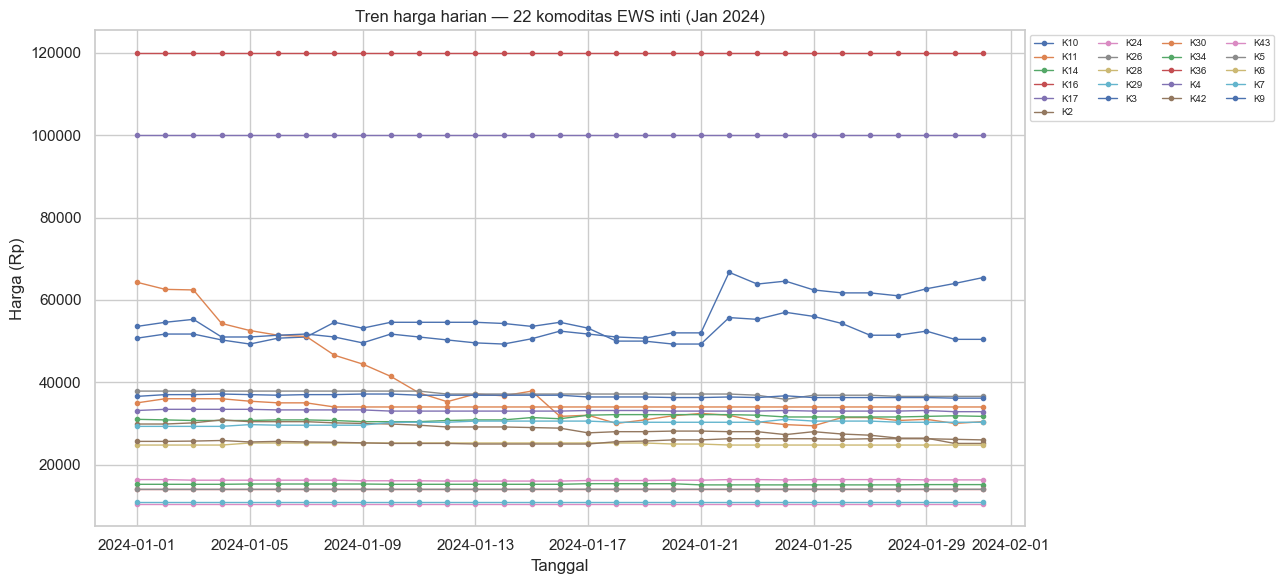

In [28]:
fig, ax = plt.subplots(figsize=(13, 6))
for kode, g in df22.groupby("kode_ews"):
    ax.plot(g["tanggal"], g["harga_rata"], marker="o", ms=3, lw=1, label=kode)
ax.set_title("Tren harga harian — 22 komoditas EWS inti (Jan 2024)")
ax.set_xlabel("Tanggal"); ax.set_ylabel("Harga (Rp)")
ax.legend(ncol=4, fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

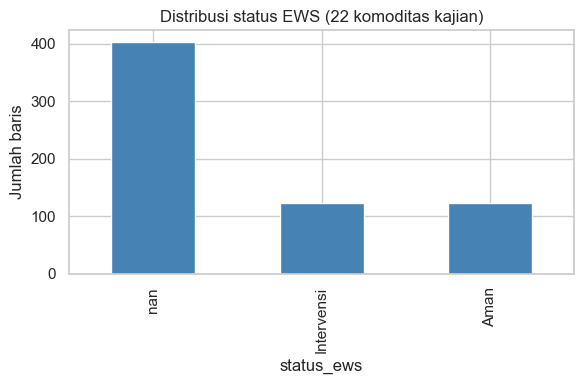

In [29]:
plt.figure(figsize=(6,4))
df22["status_ews"].value_counts(dropna=False).plot(kind="bar", color="steelblue")
plt.title("Distribusi status EWS (22 komoditas kajian)")
plt.ylabel("Jumlah baris"); plt.tight_layout(); plt.show()

## Bab 9 — Simpan hasil bersih

In [30]:
df22.to_csv(OUTPUT / "data_bersih_22.csv", index=False)
print("Disimpan:", OUTPUT / "data_bersih_22.csv")
print("Shape:", df22.shape)
print("Kolom:", list(df22.columns))

Disimpan: C:\Users\LENOVO\Documents\TOOUUGUAASS\SMT 5\BRIDA PROJECTS\notebooks\output\data_bersih_22.csv
Shape: (651, 10)
Kolom: ['komoditas', 'tanggal', 'kategori', 'het_hapk', 'harga_rata', 'fluktuasi', 'harga_tersedia', 'memiliki_het_hapk', 'kode_ews', 'status_ews']
